# Notebook 5 : Relationship Analysis & Pattern Discovery
## Overview
This notebook investigates the relationships between multiple road accident factors to identify hidden patterns influencing accident severity and casualty outcomes. Instead of analyzing variables individually, this notebook focuses on understanding how different factors interact with each other.

## Objectives
- Analyze relationships between accident variables.
- Identify factors influencing accident severity.
- Discover hidden accident patterns.
- Support data-driven road safety recommendations.

## Business Questions
1. How does traffic density influence accident severity?
2. Does poor visibility increase accident severity?
3. How does weather affect casualty count?
4. Which road type records the highest casualties?
5. Is there a relationship between traffic density and casualties?
6. Which numerical variables are strongly correlated?

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_excel("indian_roads_dataset21.xlsx")

## Analysis 1
### Business Question
How does traffic density influence accident severity?

In [34]:
traffic_severity=pd.crosstab(df["traffic_density"] , df["accident_severity"])
traffic_severity

accident_severity,fatal,major,minor
traffic_density,,,
high,1045,2077,3912
low,1061,2116,3890
medium,881,1795,3223


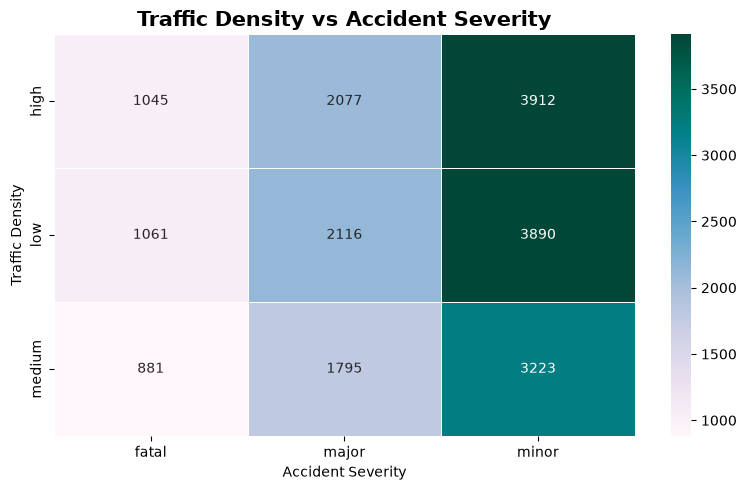

In [35]:
plt.figure(figsize=(8,5))

sns.heatmap(

    traffic_severity,

    annot=True,

    fmt="d",

    cmap="PuBuGn",

    linewidths=.5

)

plt.title(

    "Traffic Density vs Accident Severity",

    fontsize=15,

    fontweight="bold"

)

plt.xlabel("Accident Severity")

plt.ylabel("Traffic Density")

plt.tight_layout()

plt.show()

### Observation
The distribution illustrates how accident severity changes across different traffic density levels.

### Business Insight
Traffic congestion can increase collision probability and should be considered while designing intelligent traffic management systems.

## Analysis 2
### Business Question
Does poor visibility increase accident severity?

In [36]:
visibility_severity=pd.crosstab(df["visibility"],df["accident_severity"])
visibility_severity

accident_severity,fatal,major,minor
visibility,,,
high,992,2017,3681
low,1486,2988,5513
medium,509,983,1831


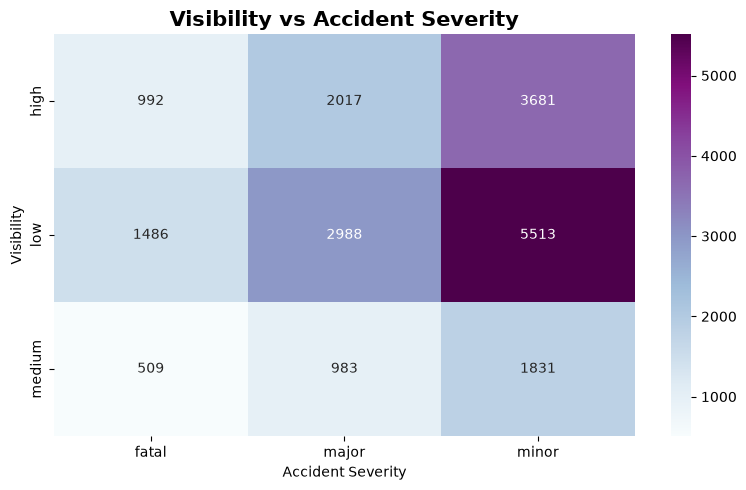

In [37]:
plt.figure(figsize=(8,5))

sns.heatmap(
    visibility_severity,
    annot=True,
    fmt="d",
    cmap="BuPu"
)

plt.title(
    "Visibility vs Accident Severity",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Accident Severity")
plt.ylabel("Visibility")

plt.tight_layout()

plt.show()

### Observation
The heatmap highlights how accident severity varies under different visibility conditions.

### Business Insight
Reduced visibility may contribute to more severe accidents, emphasizing the need for improved lighting and visibility enhancement measures.

# Analysis 3
### Business Question
How does weather condition influence accident severity?

In [51]:
weather_severity = pd.crosstab(df["weather"],df["accident_severity"])
weather_severity

accident_severity,fatal,major,minor
weather,,,
clear,992,2017,3681
fog,995,1975,3663
rain,1000,1996,3681


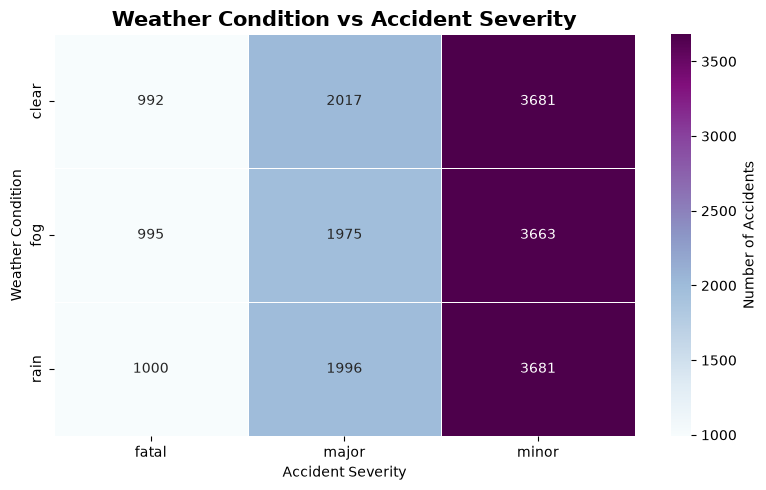

In [55]:
plt.figure(figsize=(8,5))

sns.heatmap(
    weather_severity,
    annot=True,
    fmt="d",
    cmap="BuPu",
    linewidths=.5,
    cbar_kws={"label":"Number of Accidents"}
)

plt.title(
    "Weather Condition vs Accident Severity",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Accident Severity")
plt.ylabel("Weather Condition")

plt.tight_layout()

plt.show()

### Observation
Different weather conditions show varying distributions of accident severity. Adverse weather conditions generally report a higher proportion of severe accidents.
### Business Insight
Weather-based safety measures such as warning systems, speed regulation, and real-time alerts can reduce accident severity during adverse weather conditions.

# Analysis 4
### Business Question
Which road types record the highest average casualties per accident?

In [56]:
road_casualties=df.groupby("road_type")["casualties"].mean().sort_values(ascending=False).reset_index()
road_casualties

,road_type,casualties
0,urban,1.731505
1,highway,1.725967
2,rural,1.721795


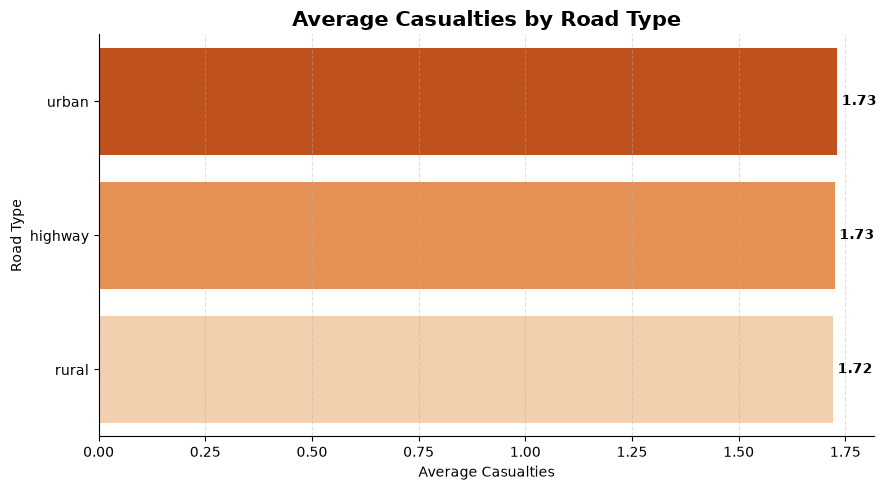

In [57]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=road_casualties,
    x="casualties",
    y="road_type",
    hue="road_type",
    palette="Oranges_r",
    legend=False
)

plt.title(
    "Average Casualties by Road Type",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Average Casualties")
plt.ylabel("Road Type")

plt.grid(axis="x",linestyle="--",alpha=0.4)

for i,v in enumerate(road_casualties["casualties"]):

    ax.text(
        v+0.01,
        i,
        f"{v:.2f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

sns.despine()

plt.tight_layout()

plt.show()

### Observation
Some road types consistently report a higher average number of casualties per accident, suggesting greater accident severity on those roads.
### Business Insight
Road segments with higher casualty rates should be prioritized for infrastructure upgrades, speed management, and safety enforcement.

# Analysis 5
### Business Question
How does traffic density influence the average number of casualties?

In [58]:
traffic_casualties = (df.groupby("traffic_density")["casualties"].mean().sort_values(ascending=False).reset_index())
traffic_casualties

,traffic_density,casualties
0,high,1.732585
1,medium,1.726394
2,low,1.720391


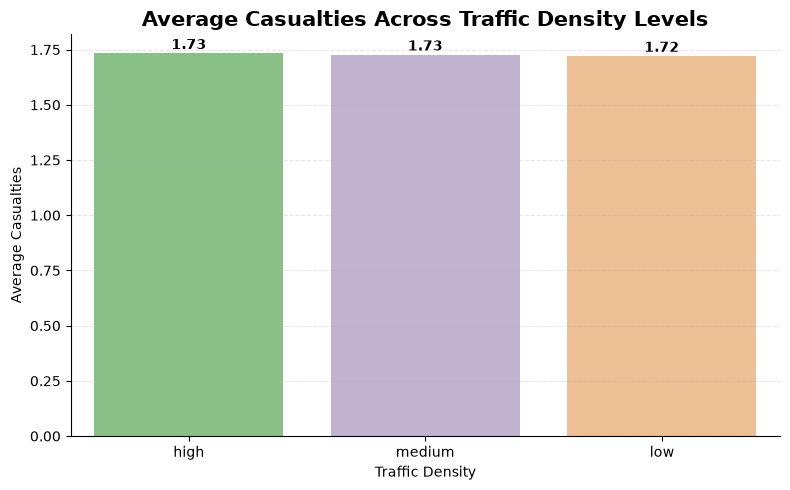

In [59]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=traffic_casualties,
    x="traffic_density",
    y="casualties",
    hue="traffic_density",
    palette="Accent",
    legend=False
)

for i, v in enumerate(traffic_casualties["casualties"]):
    ax.text(
        i,
        v + 0.02,
        f"{v:.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Average Casualties Across Traffic Density Levels",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Traffic Density")
plt.ylabel("Average Casualties")

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

### Observation
Average casualties vary across different traffic density levels, indicating that traffic congestion influences accident outcomes.
### Business Insight
High traffic density increases driving complexity and reaction time, making efficient traffic management an important factor in reducing accident severity.

### Observation
Accident frequency changes across different combinations of weather conditions and traffic density, highlighting situations where accident occurrence is more common.

### Business Insight
Traffic congestion during adverse weather conditions requires proactive traffic regulation, public safety alerts, and better emergency preparedness.

# Analysis 6
### Business Question
What are the major causes behind high-severity accidents?

In [66]:
cause_severity = pd.crosstab(df["cause"],df["accident_severity"])
cause_severity

accident_severity,fatal,major,minor
cause,,,
distraction,542,1244,2240
drunk driving,618,1164,2196
overspeeding,603,1203,2219
poor road,623,1172,2179
weather,601,1205,2191


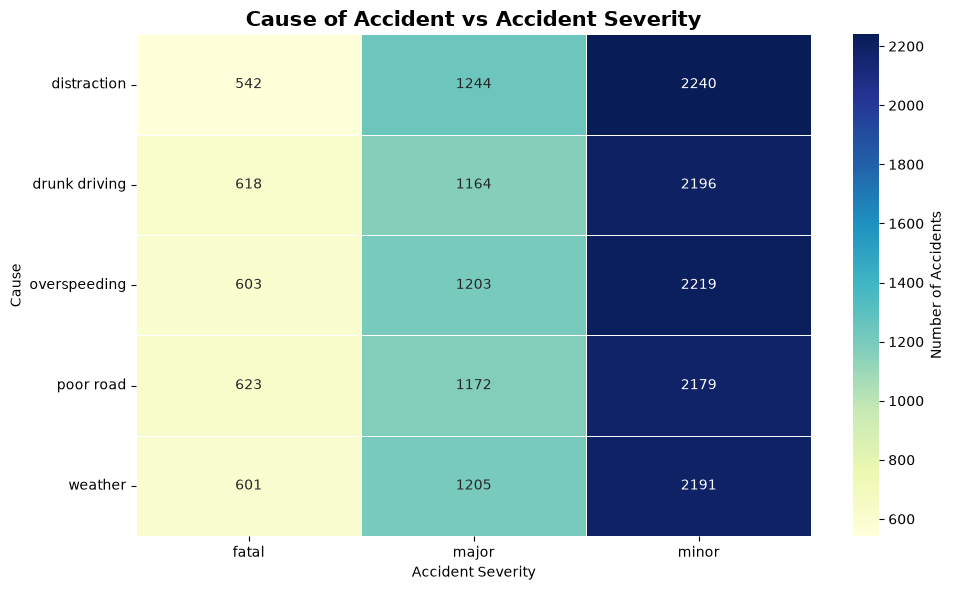

In [69]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cause_severity,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={"label":"Number of Accidents"}
)

plt.title(
    "Cause of Accident vs Accident Severity",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Accident Severity")
plt.ylabel("Cause")

plt.tight_layout()

plt.show()

# Observation
## Different accident causes contribute differently to accident severity.

# Business Insight
## Understanding the relationship between accident causes and severity helps authorities prioritize awareness campaigns, stricter law enforcement, and infrastructure improvements.

# Analysis Question 7
## Business Question
### How does the presence of traffic signals influence accident severity?

In [71]:
signal_severity = pd.crosstab(df["traffic_signal"],df["accident_severity"])
signal_severity

accident_severity,fatal,major,minor
traffic_signal,,,
0,1516,3016,5471
1,1471,2972,5554


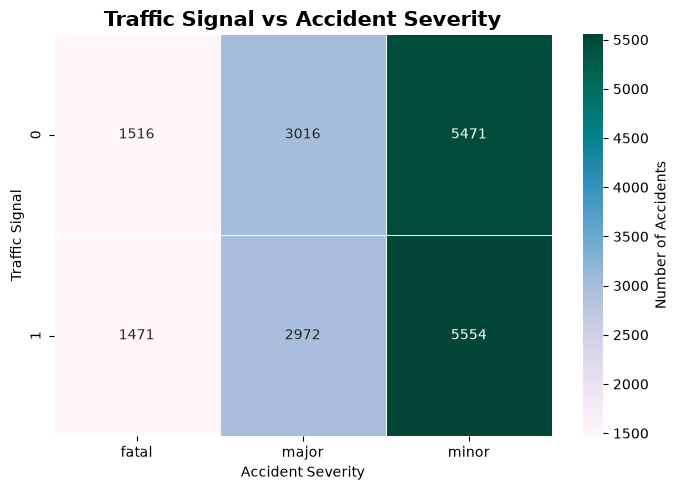

In [72]:
plt.figure(figsize=(7,5))

sns.heatmap(
    signal_severity,
    annot=True,
    fmt="d",
    cmap="PuBuGn",
    linewidths=.5,
    cbar_kws={"label":"Number of Accidents"}
)

plt.title(
    "Traffic Signal vs Accident Severity",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Accident Severity")
plt.ylabel("Traffic Signal")

plt.tight_layout()

plt.show()

# Observation
## The distribution of accident severity differs based on the presence or absence of traffic signals

# Business Insight
## Proper traffic signal management and maintenance can contribute to reducing severe road accidents, especially at busy intersections.